In [1]:
'''Requests authentication token from Sentinel Hub

from oauthlib.oauth2 import BackendApplicationClient
from requests_oauthlib import OAuth2Session


from sentinelhub import SHConfig

config = SHConfig()

# Your client credentials
client_id = '96acbb95-6c77-4d93-aaf3-ca218727e1b4'
client_secret = 'F@,ZbT*8PTZ(F}:7@.|,*;#K/K/Ev+#)uRLQ,^t2'

# Create a session
client = BackendApplicationClient(client_id=client_id)
oauth = OAuth2Session(client=client)

# Get token for the session
token = oauth.fetch_token(token_url='https://services.sentinel-hub.com/oauth/token',
                          client_secret=client_secret)

# All requests using this session will have an access token automatically added
resp = oauth.get("https://services.sentinel-hub.com/oauth/tokeninfo")
print(resp.content)

b'{"sub":"f71bef76-9296-41ab-90ac-459ffdc5f3ac","aud":"96acbb95-6c77-4d93-aaf3-ca218727e1b4","jti":"6fe2f1c4-dc5b-483b-b576-bb1fea56279c","exp":1671793864,"name":"Jakub Supera","email":"jakub.supera@gmail.com","given_name":"Jakub","family_name":"Supera","sid":"d18d0e61-6d60-4976-8b57-a0a9b5402911","did":1,"aid":"1f45fa8a-dd28-4373-bae1-3ea4c83e1c78","d":{"1":{"ra":{"rag":1},"t":12000}},"active":true}'


In [1349]:
auth = token['access_token']

In [1278]:
"""Returns dates on which cloud cover was minimal

Args:
bbox - expects it to be in format lng/lat
json_data - based of json_data_edit which can be modified
"""


import requests
def check_data (json_data_edit):
        headers = {
        'Authorization': 'Bearer ' +auth ,
        'Content-Type': 'application/json',
        }

        json_data = json.loads(json_data_edit)

        response = requests.post('https://services.sentinel-hub.com/api/v1/catalog/1.0.0/search', headers=headers, json=json_data)
        print(response.status_code)
        return response.json()
    
# Note: json_data will not be serialized by requests
# exactly as it was in the original request.
#data = '{\n      "bbox": [13,45,14,46],\n      "datetime": "2019-12-10T00:00:00Z/2019-12-10T23:59:59Z",\n      "collections": ["sentinel-2-l2a"],\n      "limit": 5,\n      "next": 5,\n"filter": "eo:cloud_cover > 90"\n  }'
#response = requests.post('https://services.sentinel-hub.com/api/v1/catalog/1.0.0/search', headers=headers, data=data)

In [1279]:
import pandas as pd
#df = pd.read_csv("capitals_final.csv")
df = pd.read_csv("capitals_bbox_fix.csv")

In [11]:
result = df['bbox'][0]
result = result.split(", ")
result

['20.2145811', '135.8536855', '35.8984245', '154.205541']

In [52]:
def bbox_fix (result):
    result = result.split(", ")
    myorder = [1, 0, 3, 2]
    result_clean = [result[i] for i in myorder]
    return str(result_clean).replace("'","")


In [53]:
df['bbox_fix'] = df['bbox'].apply(bbox_fix)

In [915]:
df_test_purposes = df[0:3]

In [1425]:
import json

def bbox_json_generator (bbox_list):
    
    """Inserts city specific bbox into json"""
    
    value = {'bbox': 0,
    
    'datetime': '2018-01-01T00:00:00Z/2022-12-31T23:59:59Z',
    'collections': [
        'sentinel-2-l2a',
    ],
    'limit': 100,
    'next': 200,
    'filter': 'eo:cloud_cover < 2',
    "fields": {
        "include": [
            "properties.datetime"
                ],
        "exclude" :['assets', 'bbox', 'geometry', 'links', 'id', 'type']
    }
    }
    value["bbox"] = json.loads(bbox_list)
    return json.dumps(value)


In [1426]:
df_singlecity["json"] = df_singlecity["bbox_fix"].apply(bbox_json_generator)

In [1339]:
df_singlecity

,Unnamed: 0.1,Unnamed: 0,city,city_ascii,lat,lng,country,iso2,iso3,admin_name,capital,population,id,bbox,bbox_fix,json,json_dates
0,0,0,Tokyo,Tokyo,35.6897,139.6922,Japan,JP,JPN,Tōkyō,primary,37977000.0,1392685764,"20.2145811, 135.8536855, 35.8984245, 154.205541","[135.8536855, 20.2145811, 154.205541, 35.8984245]","{""bbox"": [135.8536855, 20.2145811, 154.205541,...","{'type': 'FeatureCollection', 'features': [{'s..."


In [1322]:
df_singlecity = df.loc[[0]]

In [1427]:
%%time
df_singlecity["json_dates3"] = df_singlecity["json"].apply(check_data)

200
CPU times: user 40.9 ms, sys: 12.2 ms, total: 53 ms
Wall time: 3.48 s


In [1442]:
df_singlecity["json_dates3"][0]["links"][1]["body"]["next"]

300

In [1362]:
df_singlecity["json_dates"][0]["features"][0]["properties"]["datetime"]

'2022-11-22T01:20:04Z'

In [921]:
%%time
df_test_purposes["json_dates"] = df_test_purposes["json"].apply(check_data)

200
200
200
CPU times: user 134 ms, sys: 32.4 ms, total: 167 ms
Wall time: 6.93 s


<timed exec>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [928]:
df_test_purposes["json_dates"][5]["features"]

KeyError: 5

In [423]:
data_images = pd.read_json(json.dumps(df["json_dates"][0]["features"]))

In [387]:
def normalize_datetime(row):
    key = row
    #input1 = key["features"]
    data_images = pd.read_json(json.dumps(key))
    #temp_df = pd.json_normalize(data_images["properties"])
    #temp_df["city"] = row["city_ascii"]
    #result = pd.json_normalize(pd.read_json(json.dumps(df["json_dates"]+str(key)+["features"]))["properties"])
    
    return data_images

df["json_dates"].apply(normalize_datetime)

#main = pd.concat([main_dates_images, df["json_dates"].apply(normalize_datetime)], axis=1)
###next step is to make function to unpack all the info to separate dataframe

ValueError: All arrays must be of the same length

In [405]:
df_dates_cities = pd.DataFrame() 

In [957]:
df

,datetime,platform,instruments,constellation,gsd,eo:cloud_cover,proj:epsg,proj:bbox,proj:geometry.type,proj:geometry.crs.type,proj:geometry.crs.properties.name,proj:geometry.coordinates
0,2022-11-22T01:20:04Z,sentinel-2a,[msi],sentinel-2,10,0.00,32654,"[699960.0, 2690220.0, 809760.0, 2800020.0]",MultiPolygon,name,urn:ogc:def:crs:EPSG::32654,"[[[[699961.0000121922, 2800018.999949198], [69..."
1,2022-11-22T01:20:02Z,sentinel-2a,[msi],sentinel-2,10,4.69,32654,"[499980.0, 2790240.0, 609780.0, 2900040.0]",MultiPolygon,name,urn:ogc:def:crs:EPSG::32654,"[[[[499980.99999999756, 2900038.9999496057], [..."
2,2022-11-22T01:19:59Z,sentinel-2a,[msi],sentinel-2,10,1.69,32654,"[600000.0, 2790240.0, 709800.0, 2900040.0]",MultiPolygon,name,urn:ogc:def:crs:EPSG::32654,"[[[[600001.0000001065, 2900038.9999495936], [6..."
3,2022-11-22T01:19:54Z,sentinel-2a,[msi],sentinel-2,10,3.97,32654,"[699960.0, 2790240.0, 809760.0, 2900040.0]",MultiPolygon,name,urn:ogc:def:crs:EPSG::32654,"[[[[699961.0000135169, 2900038.9999493603], [6..."
4,2022-11-22T01:19:48Z,sentinel-2a,[msi],sentinel-2,10,2.32,32654,"[499980.0, 2890200.0, 609780.0, 3000000.0]",MultiPolygon,name,urn:ogc:def:crs:EPSG::32654,"[[[[499980.9999999992, 2999998.9999502245], [4..."
...,...,...,...,...,...,...,...,...,...,...,...,...
95,2022-11-11T01:48:02Z,sentinel-2a,[msi],sentinel-2,10,1.00,32653,"[499980.0, 3690240.0, 609780.0, 3800040.0]",MultiPolygon,name,urn:ogc:def:crs:EPSG::32653,"[[[[499981.0000000025, 3800038.9999784785], [4..."
96,2022-11-11T01:48:01Z,sentinel-2a,[msi],sentinel-2,10,0.00,32654,"[199980.0, 3590220.0, 309780.0, 3700020.0]",MultiPolygon,name,urn:ogc:def:crs:EPSG::32654,"[[[[199980.99949570198, 3700018.99996966], [19..."
97,2022-11-11T01:47:59Z,sentinel-2a,[msi],sentinel-2,10,0.24,32653,"[600000.0, 3690240.0, 709800.0, 3800040.0]",MultiPolygon,name,urn:ogc:def:crs:EPSG::32653,"[[[[600001.0000002678, 3800038.9999784227], [6..."
98,2022-11-11T01:47:55Z,sentinel-2a,[msi],sentinel-2,10,6.11,32653,"[699960.0, 3690240.0, 809760.0, 3800040.0]",MultiPolygon,name,urn:ogc:def:crs:EPSG::32653,"[[[[699961.000032783, 3800038.9999779244], [69..."


In [1199]:
df_main_applied.to_csv("df_main_applied.csv")

In [1243]:
data_per_city = df_main_applied.groupby(["city","datetime"]).count()

In [ ]:
# Using plotly.express
import plotly.express as px

df_1 = df_main_applied
fig = px.line(df_1, x="datetime", y="city", color="datetime", line_group="city")
fig.show()

In [1196]:
df_temp = pd.json_normalize(pd.read_json(json.dumps(df["json_dates"][208]["features"]))["properties"])
df_temp["city"] = df["city_ascii"][208]
df_main_applied = df_temp.append(df_main_applied, ignore_index=True)
df_main_applied.count()

KeyError: 208

In [747]:
import json

In [760]:
type(df["json_dates"])

pandas.core.series.Series

In [586]:
json.unstack(json_dates_df["features"])

AttributeError: module 'json' has no attribute 'unstack'

In [ ]:
df_dates_cities 


""


In [585]:
df

0      {'type': 'FeatureCollection', 'features': [{'s...
1      {'type': 'FeatureCollection', 'features': [{'s...
2      {'type': 'FeatureCollection', 'features': [{'s...
3      {'type': 'FeatureCollection', 'features': [{'s...
4      {'type': 'FeatureCollection', 'features': [{'s...
                             ...                        
201    {'type': 'FeatureCollection', 'features': [{'s...
202    {'type': 'FeatureCollection', 'features': [{'s...
203    {'type': 'FeatureCollection', 'features': [{'s...
204    {'type': 'FeatureCollection', 'features': [{'s...
205    {'type': 'FeatureCollection', 'features': [{'s...
Name: json_dates, Length: 206, dtype: object

In [393]:
main_dates_images

pandas.core.frame.DataFrame

In [256]:
main_dates_images = pd.DataFrame

In [227]:
def retrieve_dates(properties):
    main_file
    main_file["date"] = properties["date"]

,stac_version,stac_extensions,id,type,geometry,bbox,properties,assets,collection,links
0,1.0.0,[https://stac-extensions.github.io/eo/v1.0.0/s...,S2A_MSIL2A_20221118T012941_N0400_R074_T53SQV_2...,Feature,"{'type': 'MultiPolygon', 'crs': {'type': 'name...","[137.53079516588915, 35.10722746944366, 138.44...","{'datetime': '2022-11-18T01:37:28Z', 'platform...",{'data': {'href': 's3://sentinel-s2-l2a/tiles/...,sentinel-2-l2a,[{'href': 'https://services.sentinel-hub.com/a...
1,1.0.0,[https://stac-extensions.github.io/eo/v1.0.0/s...,S2A_MSIL2A_20221118T012941_N0400_R074_T54STE_2...,Feature,"{'type': 'MultiPolygon', 'crs': {'type': 'name...","[137.68467674850947, 35.11017477587564, 138.91...","{'datetime': '2022-11-18T01:37:27Z', 'platform...",{'data': {'href': 's3://sentinel-s2-l2a/tiles/...,sentinel-2-l2a,[{'href': 'https://services.sentinel-hub.com/a...
2,1.0.0,[https://stac-extensions.github.io/eo/v1.0.0/s...,S2A_MSIL2A_20221118T012941_N0400_R074_T54SUE_2...,Feature,"{'type': 'MultiPolygon', 'crs': {'type': 'name...","[138.7776148916377, 35.13501116061092, 140.009...","{'datetime': '2022-11-18T01:37:23Z', 'platform...",{'data': {'href': 's3://sentinel-s2-l2a/tiles/...,sentinel-2-l2a,[{'href': 'https://services.sentinel-hub.com/a...
3,1.0.0,[https://stac-extensions.github.io/eo/v1.0.0/s...,S2A_MSIL2A_20221118T012941_N0400_R074_T54SWE_2...,Feature,"{'type': 'MultiPolygon', 'crs': {'type': 'name...","[140.99978880082185, 35.60865927399884, 141.17...","{'datetime': '2022-11-18T01:37:11Z', 'platform...",{'data': {'href': 's3://sentinel-s2-l2a/tiles/...,sentinel-2-l2a,[{'href': 'https://services.sentinel-hub.com/a...
4,1.0.0,[https://stac-extensions.github.io/eo/v1.0.0/s...,S2B_MSIL2A_20221117T011929_N0400_R131_T54RYP_2...,Feature,"{'type': 'MultiPolygon', 'crs': {'type': 'name...","[142.9848130880157, 25.21599675599776, 143.271...","{'datetime': '2022-11-17T01:19:53Z', 'platform...",{'data': {'href': 's3://sentinel-s2-l2a/tiles/...,sentinel-2-l2a,[{'href': 'https://services.sentinel-hub.com/a...
...,...,...,...,...,...,...,...,...,...,...
95,1.0.0,[https://stac-extensions.github.io/eo/v1.0.0/s...,S2A_MSIL2A_20221105T011821_N0400_R031_T54RWQ_2...,Feature,"{'type': 'MultiPolygon', 'crs': {'type': 'name...","[140.99980828895738, 27.091110400857627, 141.0...","{'datetime': '2022-11-05T01:29:40Z', 'platform...",{'data': {'href': 's3://sentinel-s2-l2a/tiles/...,sentinel-2-l2a,[{'href': 'https://services.sentinel-hub.com/a...
96,1.0.0,[https://stac-extensions.github.io/eo/v1.0.0/s...,S2A_MSIL2A_20221105T011821_N0400_R031_T54RWR_2...,Feature,"{'type': 'MultiPolygon', 'crs': {'type': 'name...","[140.9998067130287, 27.091130445246392, 141.25...","{'datetime': '2022-11-05T01:29:30Z', 'platform...",{'data': {'href': 's3://sentinel-s2-l2a/tiles/...,sentinel-2-l2a,[{'href': 'https://services.sentinel-hub.com/a...
97,1.0.0,[https://stac-extensions.github.io/eo/v1.0.0/s...,S2A_MSIL2A_20221105T011821_N0400_R031_T54RVS_2...,Feature,"{'type': 'MultiPolygon', 'crs': {'type': 'name...","[139.97368055379124, 27.933403267793935, 141.1...","{'datetime': '2022-11-05T01:29:22Z', 'platform...",{'data': {'href': 's3://sentinel-s2-l2a/tiles/...,sentinel-2-l2a,[{'href': 'https://services.sentinel-hub.com/a...
98,1.0.0,[https://stac-extensions.github.io/eo/v1.0.0/s...,S2A_MSIL2A_20221105T011821_N0400_R031_T54RWS_2...,Feature,"{'type': 'MultiPolygon', 'crs': {'type': 'name...","[140.9998050624206, 27.938060144390175, 141.51...","{'datetime': '2022-11-05T01:29:18Z', 'platform...",{'data': {'href': 's3://sentinel-s2-l2a/tiles/...,sentinel-2-l2a,[{'href': 'https://services.sentinel-hub.com/a...


In [425]:
df.to_csv("capitals_bbox_fix_json_dates.csv")

In [958]:
df = pd.read_csv("capitals_bbox_fix.csv")

In [721]:
def importer(row):
    index = row["Unnamed: 0"]
    step1 = json.loads(json.dumps(row["json_dates"]))
    #df_temp = pd.read_json(json.dumps([0]["features"]))["properties"]
    #df_temp["city"] = row["city_ascii"]
    #df_temp
    #df_temp = pd.DataFrame(pd.json_normalize(pd.read_json(json.dumps(data1))))
    #df_temp["city"] = row["city_ascii"]
    return index,step1

df.apply(importer, axis=1)

0      (0, {'type': 'FeatureCollection', 'features': ...
1      (1, {'type': 'FeatureCollection', 'features': ...
2      (2, {'type': 'FeatureCollection', 'features': ...
3      (3, {'type': 'FeatureCollection', 'features': ...
4      (4, {'type': 'FeatureCollection', 'features': ...
                             ...                        
201    (201, {'type': 'FeatureCollection', 'features'...
202    (202, {'type': 'FeatureCollection', 'features'...
203    (203, {'type': 'FeatureCollection', 'features'...
204    (204, {'type': 'FeatureCollection', 'features'...
205    (205, {'type': 'FeatureCollection', 'features'...
Length: 206, dtype: object

In [664]:
df["json_dates"].unstack()

ValueError: index must be a MultiIndex to unstack, <class 'pandas.core.indexes.range.RangeIndex'> was passed

In [686]:
object = df["json_dates"].to_json()

In [683]:
pd.json_normalize(df["json_dates"][0]["features"])

TypeError: string indices must be integers

In [1256]:
data_plot = pd.read_csv("df_main_applied.csv")

In [1262]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.


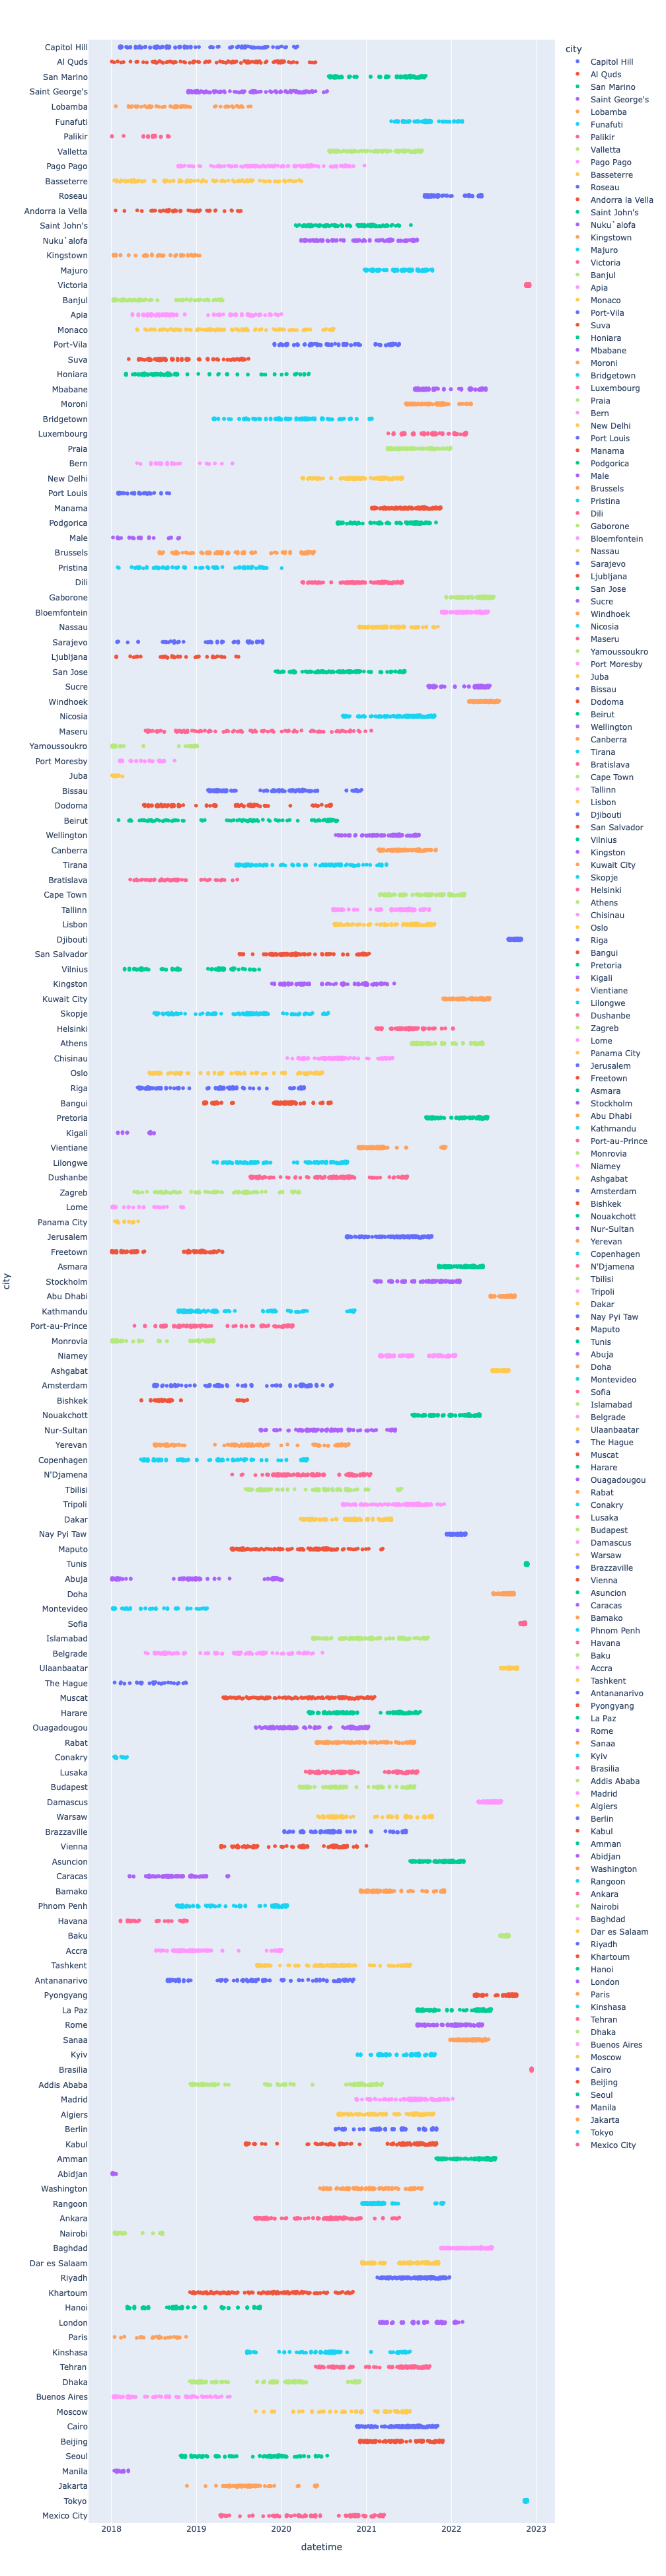

In [1275]:
import plotly.express as px
fig = px.strip(data_plot, x="datetime", y="city", orientation="h", color="city",
                 width=800, height=3900)
fig.show()